<a href="https://colab.research.google.com/github/Archak-ECE/-Matched-filtering-ISI-and-eye-diagrams/blob/main/Experiment_8_%E2%80%94_Matched_filtering%2C_ISI_and_eye_diagrams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

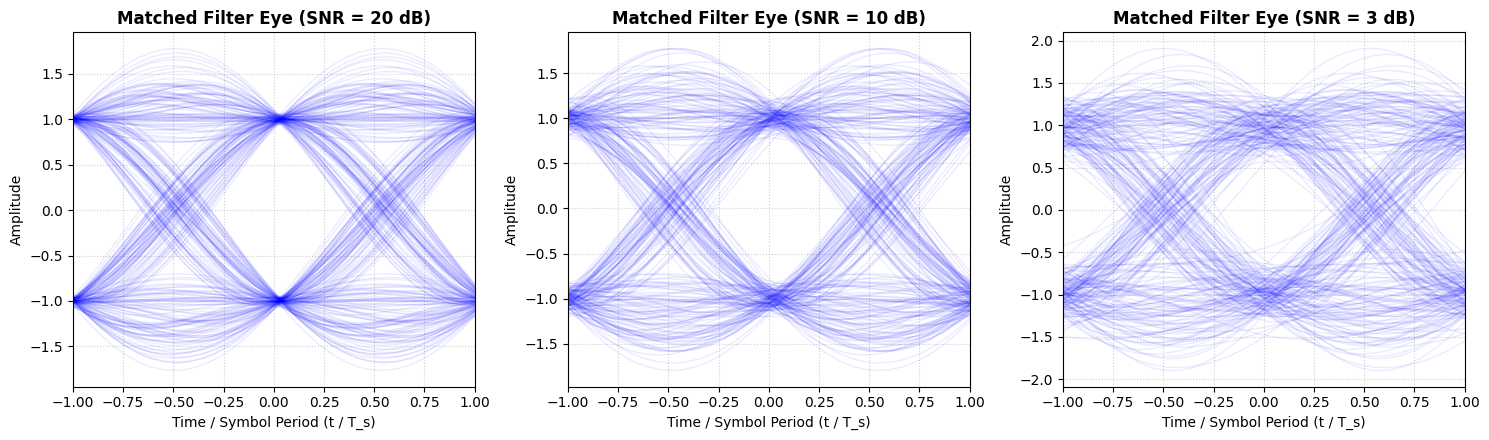

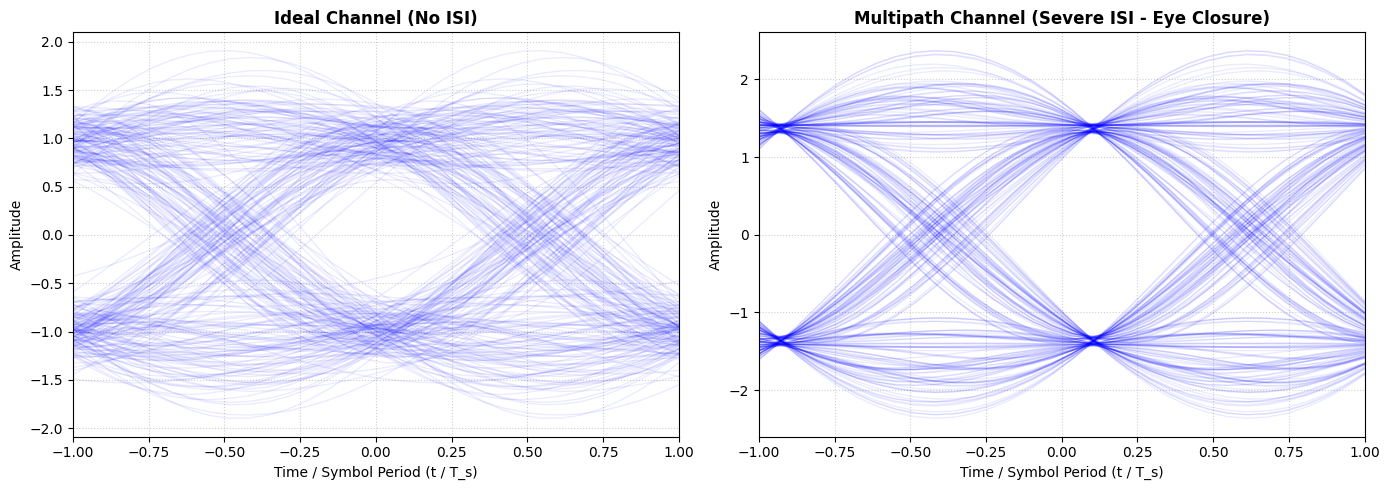

MANDATORY VALIDATION: Cascade Delay Compensation & Optimum Sampling
Filter Span (Symbols):              6
Single Filter Delay (Samples):       48
Total Cascaded System Delay:         96 samples (6.0 symbol periods)
Transmitted Bits Count:              1000
Extracted Symbol Samples Count:      1000
Noiseless Bit Errors (Post-delay):   0
Optimum Sampling Instant Validated:  PASS (0 Errors)


In [1]:
# ==============================================================================
# EXPERIMENT 08: Matched Filtering, Intersymbol Interference (ISI) and Eye Diagrams
# Platform: Google Colab / Python 3
# Required Libraries: NumPy, SciPy, Matplotlib
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Global formatting settings for Google Colab
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True

# ------------------------------------------------------------------------------
# 1. HELPER FUNCTIONS: RRC PULSE & CUSTOM EYE DIAGRAM
# ------------------------------------------------------------------------------

def root_raised_cosine(t, Ts, alpha):
    """Generates time-domain Root-Raised-Cosine (RRC) pulse response."""
    h = np.zeros_like(t, dtype=float)
    for i, ti in enumerate(t):
        if np.isclose(ti, 0.0):
            h[i] = (1.0 / Ts) * (1.0 + alpha * (4.0 / np.pi - 1.0))
        elif alpha > 0 and np.isclose(np.abs(ti), Ts / (4.0 * alpha)):
            h[i] = (alpha / (Ts * np.sqrt(2.0))) * (
                (1.0 + 2.0 / np.pi) * np.sin(np.pi / (4.0 * alpha)) +
                (1.0 - 2.0 / np.pi) * np.cos(np.pi / (4.0 * alpha))
            )
        else:
            term1 = np.sin(np.pi * (1.0 - alpha) * ti / Ts)
            term2 = (4.0 * alpha * ti / Ts) * np.cos(np.pi * (1.0 + alpha) * ti / Ts)
            numerator = term1 + term2
            denominator = (np.pi * ti / Ts) * (1.0 - (4.0 * alpha * ti / Ts) ** 2)
            h[i] = (1.0 / Ts) * (numerator / denominator)

    return h / np.sqrt(np.sum(h ** 2))  # Unit energy normalization


def plot_eye_diagram(signal_in, sps, eye_periods=2, title="Eye Diagram", ax=None):
    """
    Constructs an Eye Diagram by slicing continuous waveform into overlapping segments.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    samples_per_eye = eye_periods * sps
    num_traces = (len(signal_in) - samples_per_eye) // sps

    t_eye = np.linspace(-eye_periods / 2, eye_periods / 2, samples_per_eye)

    for i in range(num_traces):
        start_idx = i * sps
        end_idx = start_idx + samples_per_eye
        ax.plot(t_eye, signal_in[start_idx:end_idx], color='blue', alpha=0.08, linewidth=1)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Time / Symbol Period (t / T_s)", fontsize=10)
    ax.set_ylabel("Amplitude", fontsize=10)
    ax.set_xlim(-eye_periods / 2, eye_periods / 2)
    ax.grid(True, linestyle=':', alpha=0.6)


# ------------------------------------------------------------------------------
# 2. SYSTEM SIMULATION PARAMETERS
# ------------------------------------------------------------------------------
np.random.seed(42)
num_bits = 1000
Ts = 1.0              # Symbol duration
sps = 16              # Samples per symbol
span = 6              # Filter span in symbols
alpha = 0.35          # Roll-off factor

# Generate BPSK bits (+1 and -1)
bits = 2 * np.random.randint(0, 2, num_bits) - 1

# Time vector for filter
t_filter = np.linspace(-span * Ts / 2, span * Ts / 2, span * sps + 1)
h_rrc = root_raised_cosine(t_filter, Ts, alpha)

# 1. Transmitter: Upsampling and Pulse Shaping
tx_upsampled = np.zeros(num_bits * sps)
tx_upsampled[::sps] = bits
tx_signal = np.convolve(tx_upsampled, h_rrc, mode='full')

# Delay calculations
filter_delay = (len(h_rrc) - 1) // 2
total_delay = 2 * filter_delay  # Tx RRC + Rx Matched RRC delay

# ------------------------------------------------------------------------------
# 3. NOISE & MATCHED FILTERING AT VARIOUS SNRS
# ------------------------------------------------------------------------------
snr_levels_db = [20, 10, 3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, snr_db in enumerate(snr_levels_db):
    # Add AWGN channel noise
    signal_power = np.mean(tx_signal ** 2)
    snr_linear = 10 ** (snr_db / 10.0)
    noise_variance = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_variance), len(tx_signal))
    rx_noisy = tx_signal + noise

    # 2. Receiver: Matched Filtering (Convolve with identical RRC)
    mf_output = np.convolve(rx_noisy, h_rrc, mode='full')

    # Extract steady-state portion for eye diagram after removing filter transient
    eye_signal = mf_output[total_delay : total_delay + 300 * sps]

    plot_eye_diagram(eye_signal, sps, eye_periods=2,
                     title=f"Matched Filter Eye (SNR = {snr_db} dB)", ax=axes[idx])

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4. MULTIPATH CHANNEL & ISI DEMONSTRATION
# ------------------------------------------------------------------------------
# Create a multipath ISI channel: Direct path + delayed path
channel_isi = np.array([1.0, 0.0, 0.0, 0.0, 0.4])  # Echo at 4 samples offset
tx_isi = np.convolve(tx_signal, channel_isi, mode='full')

# Receiver Matched Filter
rx_isi_filtered = np.convolve(tx_isi, h_rrc, mode='full')
eye_isi_signal = rx_isi_filtered[total_delay : total_delay + 300 * sps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_eye_diagram(eye_signal, sps, eye_periods=2, title="Ideal Channel (No ISI)", ax=ax1)
plot_eye_diagram(eye_isi_signal, sps, eye_periods=2, title="Multipath Channel (Severe ISI - Eye Closure)", ax=ax2)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. MANDATORY VALIDATION: DELAY COMPENSATED OPTIMUM SAMPLING
# ------------------------------------------------------------------------------
# Clean channel matched filter output
mf_clean = np.convolve(tx_signal, h_rrc, mode='full')

# Sample at optimum instants (after accounting for total_delay)
rx_symbols = mf_clean[total_delay : total_delay + num_bits * sps : sps]

# Measure Bit Error Rate on noiseless system
rx_bits = np.sign(rx_symbols)
errors = np.sum(bits != rx_bits)

print("=" * 70)
print("MANDATORY VALIDATION: Cascade Delay Compensation & Optimum Sampling")
print("=" * 70)
print(f"Filter Span (Symbols):              {span}")
print(f"Single Filter Delay (Samples):       {filter_delay}")
print(f"Total Cascaded System Delay:         {total_delay} samples ({total_delay / sps:.1f} symbol periods)")
print(f"Transmitted Bits Count:              {num_bits}")
print(f"Extracted Symbol Samples Count:      {len(rx_symbols)}")
print(f"Noiseless Bit Errors (Post-delay):   {errors}")
print(f"Optimum Sampling Instant Validated:  {'PASS (0 Errors)' if errors == 0 else 'FAIL'}")
print("=" * 70)